In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 1. දත්ත ඇතුළත් කරගැනීම
df = pd.read_csv('diabetes1.csv')

# දත්ත වල හැඩය බලමු
print("Data Shape:", df.shape)

Data Shape: (253680, 22)


C:\Users\lahir\AppData\Local\Temp\ipykernel_17248\3108581119.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HighChol', data=df, ax=axes[0], palette='Set1')


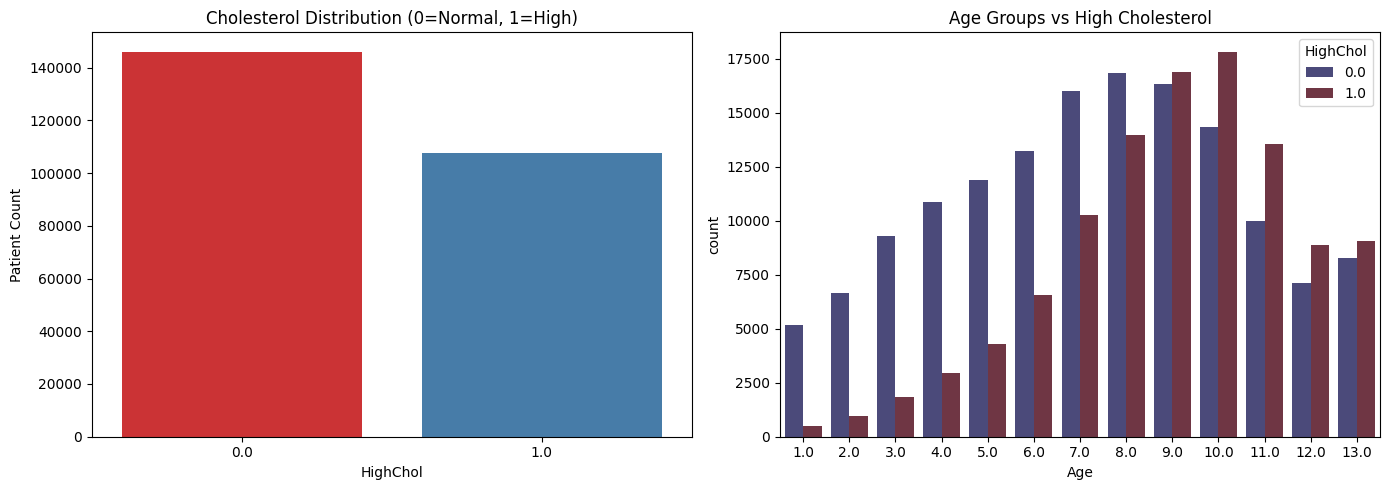

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: කොලෙස්ටරෝල් ඇති සහ නැති අයගේ ව්‍යාප්තිය (Target)
sns.countplot(x='HighChol', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('Cholesterol Distribution (0=Normal, 1=High)')
axes[0].set_ylabel('Patient Count')

# Graph 2: වයස සහ අධික කොලෙස්ටරෝල් අතර සම්බන්ධය
sns.countplot(x='Age', hue='HighChol', data=df, ax=axes[1], palette='icefire')
axes[1].set_title('Age Groups vs High Cholesterol')

plt.tight_layout()
plt.show()

In [4]:
# 1. අනවශ්‍ය Columns ඉවත් කිරීම
columns_to_drop = ['AnyHealthcare', 'NoDocbcCost', 'Education', 'Income']
df_cleaned = df.drop(columns=columns_to_drop)

# 2. BMI වල තියෙන Outliers ඉවත් කිරීම
df_cleaned = df_cleaned[(df_cleaned['BMI'] >= 12) & (df_cleaned['BMI'] <= 70)]

# 3. Features (X) සහ Target (y) වෙන් කරගැනීම
# මෙවර Target එක HighChol වේ
X = df_cleaned.drop(columns=['HighChol'])
y = df_cleaned['HighChol']

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Cholesterol Data Preprocessing අවසන්!")

✅ Cholesterol Data Preprocessing අවසන්!


In [5]:
# 1. දත්ත 80% සහ 20% ලෙස බෙදීම
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. XGBoost Model එක සාදා Train කිරීම
chol_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
chol_model.fit(X_train, y_train)

# 3. අනාවැකි ලබා ගැනීම
y_pred = chol_model.predict(X_test)

# 4. ප්‍රතිඵල පරීක්ෂා කිරීම
print(f"🎯 Cholesterol Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📋 Detailed Classification Report:\n", classification_report(y_test, y_pred))

🎯 Cholesterol Model Accuracy: 68.33%

📋 Detailed Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      0.77      0.74     29136
         1.0       0.64      0.57      0.60     21484

    accuracy                           0.68     50620
   macro avg       0.68      0.67      0.67     50620
weighted avg       0.68      0.68      0.68     50620



In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# 1. පරීක්ෂා කිරීමට අවශ්‍ය ඇල්ගොරිතම ලැයිස්තුව
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'XGBoost (Default)': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'XGBoost (Balanced)': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, scale_pos_weight=3.5, random_state=42, eval_metric='logloss')
}

# ප්‍රතිඵල එකතු කරගන්න හිස් ලැයිස්තුවක්
results = []

# 2. Loop එකක් මගින් හැම Model එකක්ම Train කරලා Metrics බලමු
for name, model in models.items():
    # Model එක පුහුණු කිරීම
    model.fit(X_train, y_train)
    # අනාවැකි ගැනීම
    y_pred = model.predict(X_test)
    
    # Metrics ගණනය කිරීම
    acc = accuracy_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    
    # ප්‍රතිඵල එකතු කිරීම
    results.append({
        'Model Name': name,
        'Accuracy (%)': round(acc, 2),
        'Recall (Class 1) (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2)
    })

# 3. ප්‍රතිඵල ලස්සන DataFrame වගුවක් විදිහට පෙන්වීම
df_results = pd.DataFrame(results)
df_results.sort_values(by='Accuracy (%)', ascending=False)

,Model Name,Accuracy (%),Recall (Class 1) (%),F1-Score (%)
2,XGBoost (Default),68.33,56.93,60.41
1,Random Forest,68.07,56.20,59.90
0,Logistic Regression,67.67,54.57,58.90
3,XGBoost (Balanced),57.21,93.67,65.01


In [7]:
# කොලෙස්ටරෝල් මොඩල් එක සේව් කිරීම
chol_model.save_model('chol_model.json')
print("Cholesterol Model Saved!")

Cholesterol Model Saved!
